# Color Spaces & Channel Processing
## Computer Vision Practice - Week 2, Day 1 (Monday)

**Objective:** Master different color spaces and image channel operations.

**Topics:**
- RGB and BGR color spaces
- HSV (Hue, Saturation, Value) color space
- LAB color space
- YUV and Grayscale conversions
- Channel splitting and merging
- Color-based image processing and filtering

## 1. Libraries & Setup

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 2. What is a Color Space?

A **color space** is a way to represent colors in an image. Different color spaces help us:
- Extract specific information from images
- Make image processing easier
- Separate color, brightness, and saturation for better control

Think of it like different languages for describing the same color:
- **RGB**: "This pixel has Red=255, Green=100, Blue=50"
- **HSV**: "This pixel has Hue=20°, Saturation=80%, Brightness=100%"
- **Grayscale**: "This pixel has brightness=150"

Each language is useful for different tasks!

## 3. RGB vs BGR Color Space

**RGB (Red, Green, Blue)** - Standard for most software
- Each pixel = 3 values: Red (0-255), Green (0-255), Blue (0-255)
- Pure Red: (255, 0, 0)
- Pure Green: (0, 255, 0)
- Pure Blue: (0, 0, 255)

**BGR (Blue, Green, Red)** - OpenCV's default
- OpenCV reads images as BGR instead of RGB!
- Same colors, different order: (Blue, Green, Red)
- This is why images look wrong if you don't convert

**Quick Tip:** Always convert BGR to RGB before displaying with Matplotlib!

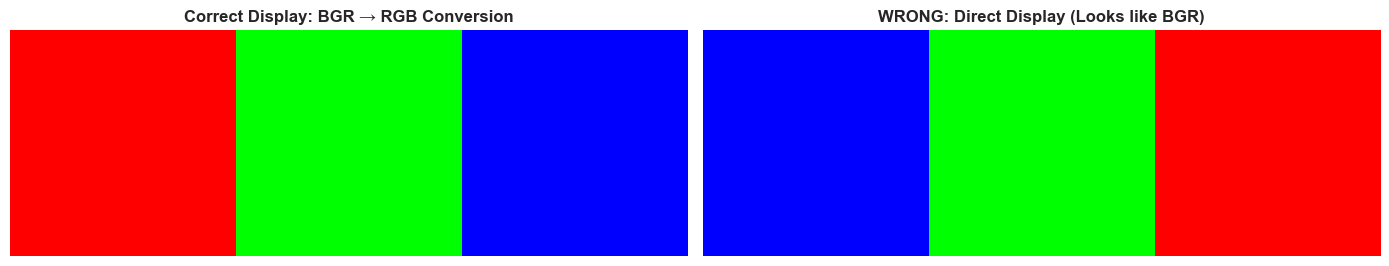

Notice how colors are wrong in the right image? That's because OpenCV uses BGR!

Key conversion functions:
- cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  → Convert BGR to RGB
- cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  → Convert RGB to BGR


In [2]:
# --- MORNING SESSION: RGB/BGR Theory ---

# Create a simple test image with solid colors
test_image = np.zeros((200, 600, 3), dtype=np.uint8)

# Left section: Red in BGR
test_image[0:200, 0:200] = [0, 0, 255]  # BGR: (0,0,255) = Red

# Middle section: Green in BGR
test_image[0:200, 200:400] = [0, 255, 0]  # BGR: (0,255,0) = Green

# Right section: Blue in BGR
test_image[0:200, 400:600] = [255, 0, 0]  # BGR: (255,0,0) = Blue

# Display the image
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Show as BGR (OpenCV format)
axes[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Correct Display: BGR → RGB Conversion', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Show as RGB (without conversion - wrong colors!)
axes[1].imshow(test_image)
axes[1].set_title('WRONG: Direct Display (Looks like BGR)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Notice how colors are wrong in the right image? That's because OpenCV uses BGR!")
print("\nKey conversion functions:")
print("- cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  → Convert BGR to RGB")
print("- cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  → Convert RGB to BGR")

## 4. HSV Color Space (Hue, Saturation, Value)

**HSV** separates color information into three components:

- **Hue (0-180 in OpenCV)**: The actual color (red, green, blue, yellow, etc.)
  - 0° = Red, 60° = Green, 120° = Blue
  
- **Saturation (0-255)**: How "pure" the color is
  - 0 = Gray (no color)
  - 255 = Pure, vibrant color
  
- **Value (0-255)**: Brightness/Lightness
  - 0 = Black
  - 255 = Bright

**Why HSV is useful:**
- Perfect for detecting objects by color (e.g., red ball, green leaf)
- Separates brightness from color - more intuitive for humans
- Used in color detection pipelines

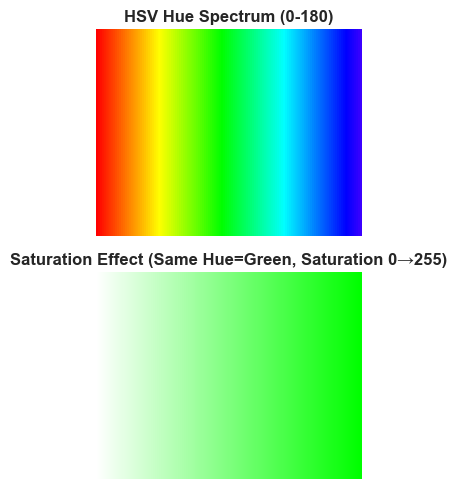

HSV is perfect for color-based detection!
Low saturation = grayish colors
High saturation = vibrant colors


In [3]:
# --- HSV Visualization ---

# Create colorful test image with gradients
hsv_image = np.zeros((200, 256, 3), dtype=np.uint8)

# Create gradient: Hue changes from 0 to 180 (all colors)
for i in range(256):
    hsv_image[:, i] = [i//2, 255, 255]  # Constant saturation and value

# Convert HSV to BGR for display
hsv_display = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2BGR)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# Display HSV color spectrum
axes[0].imshow(cv2.cvtColor(hsv_display, cv2.COLOR_BGR2RGB))
axes[0].set_title('HSV Hue Spectrum (0-180)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hue Value (0-180)')
axes[0].axis('off')

# Show saturation effect
sat_image = np.zeros((200, 256, 3), dtype=np.uint8)
for i in range(256):
    sat_image[:, i] = [60, i, 255]  # Red hue (60), saturation varies, full value
    
sat_display = cv2.cvtColor(sat_image, cv2.COLOR_HSV2BGR)
axes[1].imshow(cv2.cvtColor(sat_display, cv2.COLOR_BGR2RGB))
axes[1].set_title('Saturation Effect (Same Hue=Green, Saturation 0→255)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Saturation (0-255)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("HSV is perfect for color-based detection!")
print("Low saturation = grayish colors")
print("High saturation = vibrant colors")

## 5. LAB and Grayscale Color Spaces

**LAB Color Space:**
- **L**: Lightness (0-100)
- **A**: Green-Red axis (-127 to 127)
- **B**: Blue-Yellow axis (-127 to 127)
- Device-independent (same colors look same across different displays)
- Great for color analysis and segmentation

**Grayscale:**
- Single channel: brightness only (0-255)
- Used for: edge detection, face recognition, simple analysis
- Conversion formula: Gray = 0.299*R + 0.587*G + 0.114*B

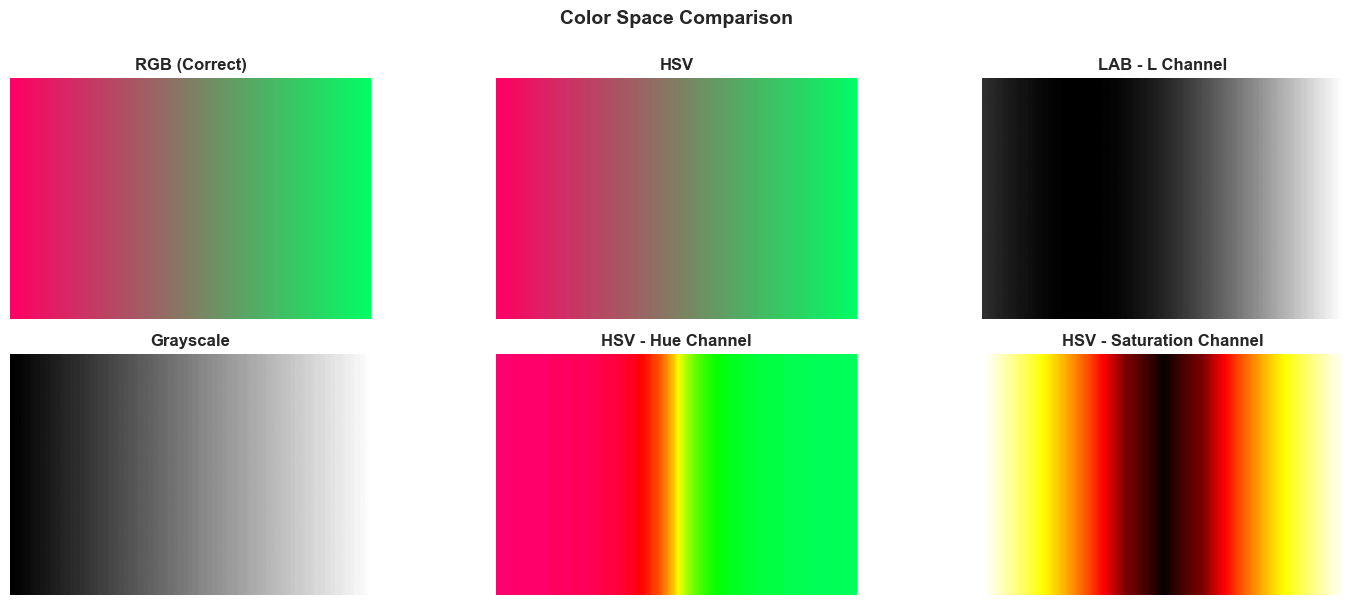

In [4]:
# --- AFTERNOON SESSION: Practical Color Space Conversions ---

# Create a colorful test image (gradient)
test_img = np.zeros((200, 300, 3), dtype=np.uint8)
for i in range(300):
    test_img[:, i] = [100, i*255//300, 255-i*255//300]  # BGR gradient

# Convert to different color spaces
bgr_img = test_img
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
lab_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)
gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

# Display all color spaces
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

# BGR (wrong display)
axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title('RGB (Correct)', fontweight='bold')
axes[0, 0].axis('off')

# HSV (visualize)
hsv_display = cv2.cvtColor(hsv_img, cv2.COLOR_HSV2BGR)
axes[0, 1].imshow(cv2.cvtColor(hsv_display, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('HSV', fontweight='bold')
axes[0, 1].axis('off')

# LAB (visualize L channel)
axes[0, 2].imshow(lab_img[:,:,0], cmap='gray')
axes[0, 2].set_title('LAB - L Channel', fontweight='bold')
axes[0, 2].axis('off')

# Grayscale
axes[1, 0].imshow(gray_img, cmap='gray')
axes[1, 0].set_title('Grayscale', fontweight='bold')
axes[1, 0].axis('off')

# HSV Hue channel
axes[1, 1].imshow(hsv_img[:,:,0], cmap='hsv')
axes[1, 1].set_title('HSV - Hue Channel', fontweight='bold')
axes[1, 1].axis('off')

# HSV Saturation channel
axes[1, 2].imshow(hsv_img[:,:,1], cmap='hot')
axes[1, 2].set_title('HSV - Saturation Channel', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Color Space Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Channel Splitting & Merging

**Channel Splitting:** Separate an image into individual color channels
**Channel Merging:** Combine channels back into an image

This is useful for:
- Analyzing individual color components
- Creating special effects
- Modifying specific color channels

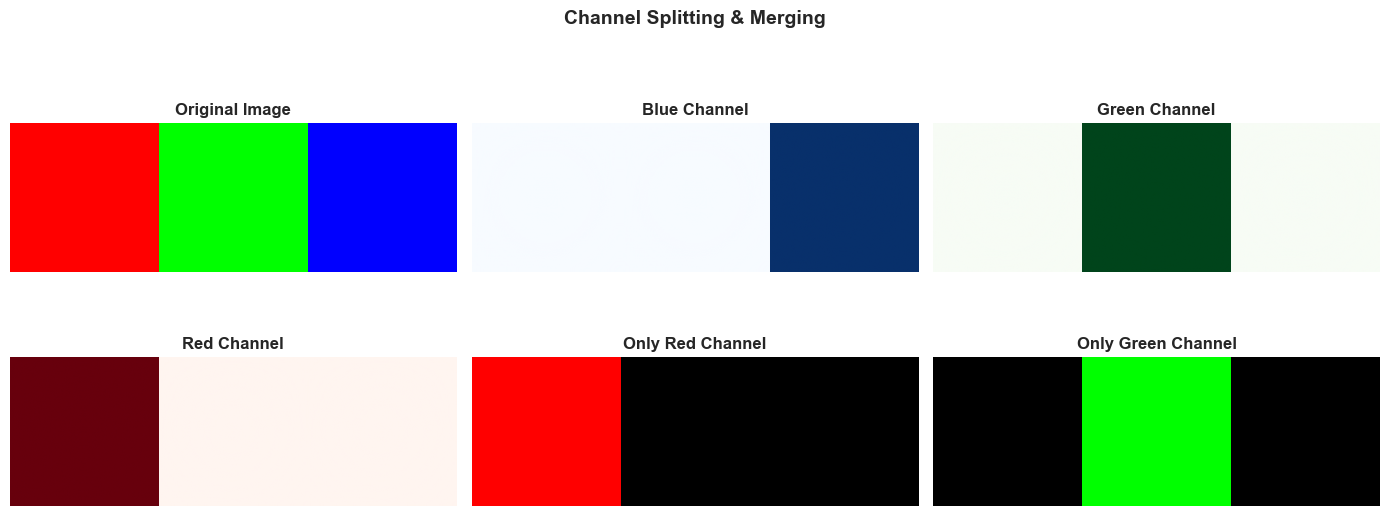

✓ Channel splitting/merging complete!
Use cv2.split() to separate channels
Use cv2.merge() to combine channels


In [5]:
# --- Channel Splitting Demo ---

# Create a multi-colored image
multi_color = np.zeros((150, 450, 3), dtype=np.uint8)
multi_color[0:150, 0:150] = [0, 0, 255]      # Red (BGR)
multi_color[0:150, 150:300] = [0, 255, 0]    # Green
multi_color[0:150, 300:450] = [255, 0, 0]    # Blue

# Split channels
b_channel, g_channel, r_channel = cv2.split(multi_color)

# Merge channels (rearrange)
rgb_reconstructed = cv2.merge([r_channel, g_channel, b_channel])

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

# Original
axes[0, 0].imshow(cv2.cvtColor(multi_color, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image', fontweight='bold')
axes[0, 0].axis('off')

# Individual channels
axes[0, 1].imshow(b_channel, cmap='Blues')
axes[0, 1].set_title('Blue Channel', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(g_channel, cmap='Greens')
axes[0, 2].set_title('Green Channel', fontweight='bold')
axes[0, 2].axis('off')

# Combined examples
axes[1, 0].imshow(r_channel, cmap='Reds')
axes[1, 0].set_title('Red Channel', fontweight='bold')
axes[1, 0].axis('off')

# Only Red channel visible
only_red = cv2.merge([np.zeros_like(r_channel), np.zeros_like(g_channel), r_channel])
axes[1, 1].imshow(cv2.cvtColor(only_red, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Only Red Channel', fontweight='bold')
axes[1, 1].axis('off')

# Only Green channel visible
only_green = cv2.merge([np.zeros_like(r_channel), g_channel, np.zeros_like(r_channel)])
axes[1, 2].imshow(cv2.cvtColor(only_green, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Only Green Channel', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Channel Splitting & Merging', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Channel splitting/merging complete!")
print("Use cv2.split() to separate channels")
print("Use cv2.merge() to combine channels")

## 7. Practical Project: Color Range Detection

**Goal:** Detect objects of a specific color in an image using HSV thresholding

**Why HSV is better than RGB for this:**
- RGB: Color detection is hard because R, G, B values are correlated
- HSV: We can easily specify a hue range, making color detection simple and robust

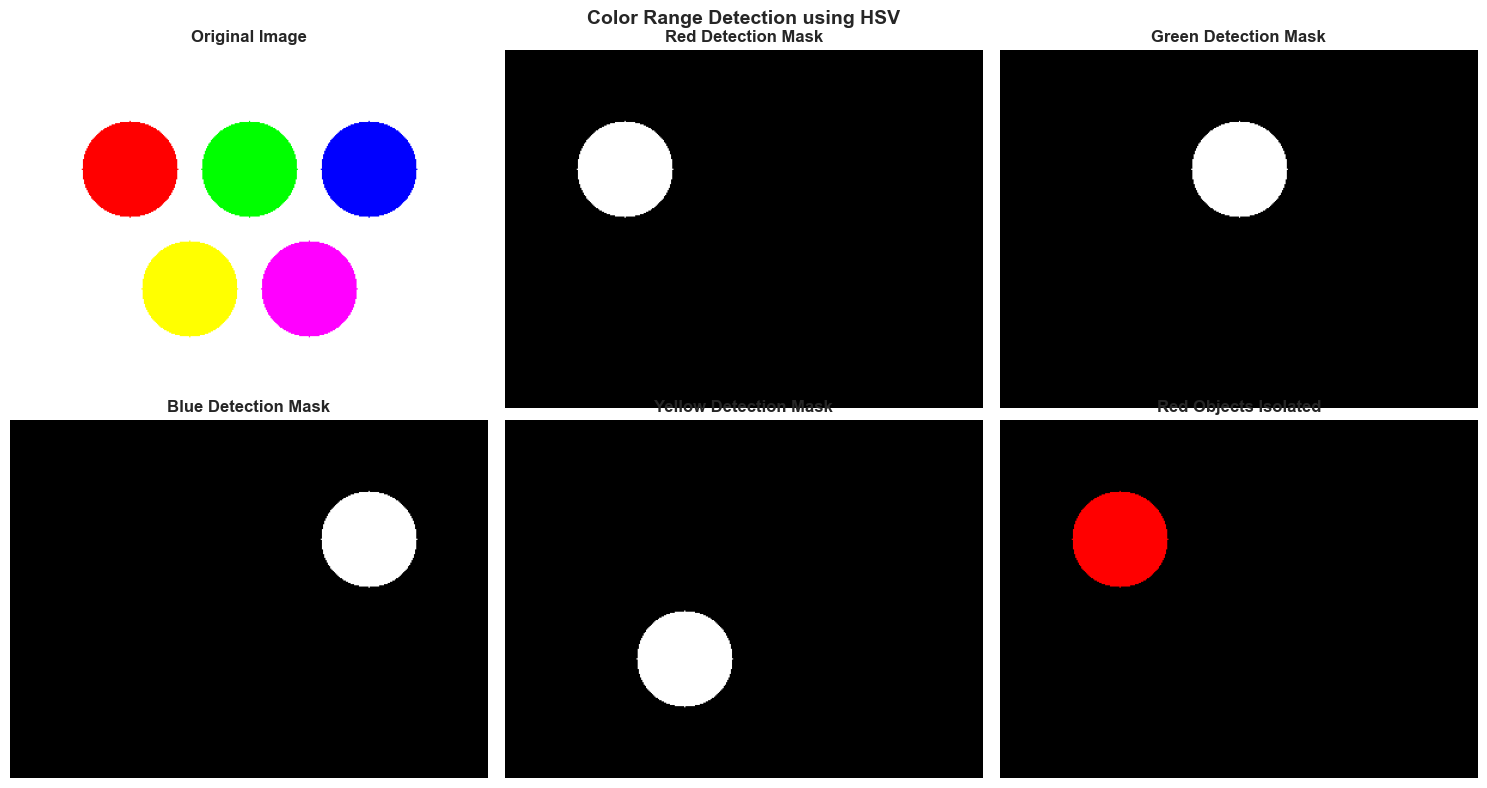

✓ Color detection complete!

Red pixels detected: 5025
Green pixels detected: 5025
Blue pixels detected: 5025
Yellow pixels detected: 5025


In [6]:
# --- Color Range Detection Project ---

# Create a test image with colored circles
canvas = np.ones((300, 400, 3), dtype=np.uint8) * 255

# Draw circles in different colors (BGR format)
cv2.circle(canvas, (100, 100), 40, (0, 0, 255), -1)      # Red
cv2.circle(canvas, (200, 100), 40, (0, 255, 0), -1)      # Green
cv2.circle(canvas, (300, 100), 40, (255, 0, 0), -1)      # Blue
cv2.circle(canvas, (150, 200), 40, (0, 255, 255), -1)    # Yellow
cv2.circle(canvas, (250, 200), 40, (255, 0, 255), -1)    # Magenta

# Convert to HSV for color detection
hsv = cv2.cvtColor(canvas, cv2.COLOR_BGR2HSV)

# Define color ranges in HSV (adjust these for different colors)
# Format: cv2.inRange(image, lower_hsv, upper_hsv)

# Red range
red_lower = np.array([0, 100, 100])
red_upper = np.array([10, 255, 255])
red_mask = cv2.inRange(hsv, red_lower, red_upper)

# Green range
green_lower = np.array([50, 100, 100])
green_upper = np.array([70, 255, 255])
green_mask = cv2.inRange(hsv, green_lower, green_upper)

# Blue range
blue_lower = np.array([100, 100, 100])
blue_upper = np.array([130, 255, 255])
blue_mask = cv2.inRange(hsv, blue_lower, blue_upper)

# Yellow range
yellow_lower = np.array([20, 100, 100])
yellow_upper = np.array([40, 255, 255])
yellow_mask = cv2.inRange(hsv, yellow_lower, yellow_upper)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original image
axes[0, 0].imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image', fontweight='bold')
axes[0, 0].axis('off')

# Red detection
axes[0, 1].imshow(red_mask, cmap='gray')
axes[0, 1].set_title('Red Detection Mask', fontweight='bold')
axes[0, 1].axis('off')

# Green detection
axes[0, 2].imshow(green_mask, cmap='gray')
axes[0, 2].set_title('Green Detection Mask', fontweight='bold')
axes[0, 2].axis('off')

# Blue detection
axes[1, 0].imshow(blue_mask, cmap='gray')
axes[1, 0].set_title('Blue Detection Mask', fontweight='bold')
axes[1, 0].axis('off')

# Yellow detection
axes[1, 1].imshow(yellow_mask, cmap='gray')
axes[1, 1].set_title('Yellow Detection Mask', fontweight='bold')
axes[1, 1].axis('off')

# Combined colored results
red_result = cv2.bitwise_and(canvas, canvas, mask=red_mask)
axes[1, 2].imshow(cv2.cvtColor(red_result, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Red Objects Isolated', fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Color Range Detection using HSV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Color detection complete!")
print(f"\nRed pixels detected: {np.sum(red_mask) // 255}")
print(f"Green pixels detected: {np.sum(green_mask) // 255}")
print(f"Blue pixels detected: {np.sum(blue_mask) // 255}")
print(f"Yellow pixels detected: {np.sum(yellow_mask) // 255}")